<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul_5_Operasi_Aritmatika_dan_Logika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math
from math import log10, sqrt

## Percobaan 1 — Gamma Correction

Masukkan nilai Gamma: 10


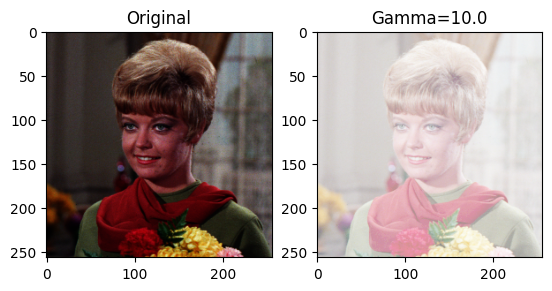

In [2]:
img = cv.imread('/content/female.tiff')
gamma = float(input("Masukkan nilai Gamma: "))
gamma_corrected = np.array(255 * (img / 255) ** (1 / gamma), dtype='uint8')

plt.subplot(1,2,1); plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); plt.title('Original')
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(gamma_corrected, cv.COLOR_BGR2RGB)); plt.title(f'Gamma={gamma}')
plt.show()

## Percobaan 2 — Simulasi Image Depth

Masukkan nilai bit depth (1-7): 7


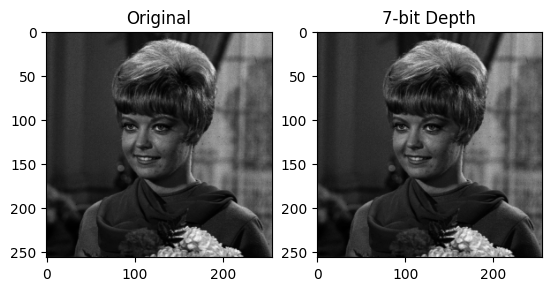

In [3]:
bit_depth = int(input("Masukkan nilai bit depth (1-7): "))
level = 255 / (pow(2, bit_depth) - 1)
img = cv.imread('/content/female.tiff', cv.IMREAD_GRAYSCALE)
depth_image = np.round((img / level)) * level
depth_image = depth_image.astype(np.uint8)

plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(1,2,2); plt.imshow(depth_image, cmap='gray'); plt.title(f'{bit_depth}-bit Depth')
plt.show()

## Percobaan 3 — Average Denoising + PSNR

In [23]:
import cv2 as cv
import numpy as np
import os

# Path file asli
orig_path = '/content/galaxy.jpg'

# Load citra asli grayscale
orig = cv.imread(orig_path, cv.IMREAD_GRAYSCALE)

# Folder output noise
output_folder = '/content/drive/MyDrive/PCVK/noises'

# Buat folder jika belum ada
os.makedirs(output_folder, exist_ok=True)

# Generate 100 noisy images
for i in range(100):
    noise = np.random.normal(0, 25, orig.shape).astype(np.float32)  # Gaussian (mean=0, std=25)
    noisy_img = orig.astype(np.float32) + noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    cv.imwrite(f'{output_folder}/noisy_{i+1}.jpg', noisy_img)

print("✅ 100 gambar noisy berhasil dibuat!")

✅ 100 gambar noisy berhasil dibuat!



=== Tabel Hasil PSNR ===


,Jumlah Citra di Average,Nilai PSNR (dB)
0,5,30.02
1,10,30.57
2,20,31.23
3,40,31.95
4,80,32.49
5,100,32.63



=== Hasil Average Denoising ===
Hasil dengan N = 5


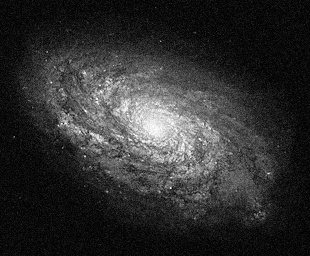

Hasil dengan N = 10


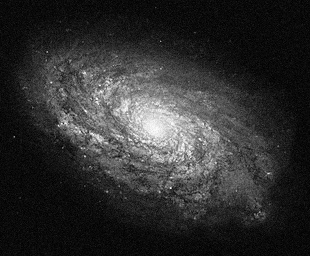

Hasil dengan N = 20


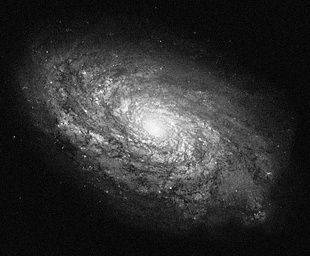

Hasil dengan N = 40


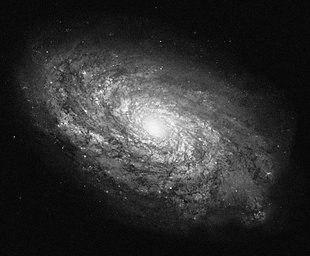

Hasil dengan N = 80


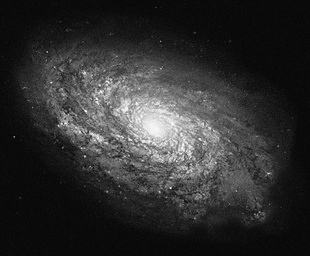

Hasil dengan N = 100


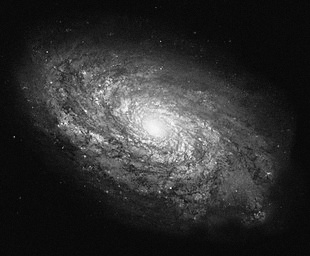

In [25]:
import pandas as pd
from google.colab.patches import cv2_imshow

# Data yang sudah dihitung sebelumnya
jumlah_images = [5, 10, 20, 40, 80, 100]

# PSNR results sudah dihitung pada step sebelumnya
# Jika belum, jalankan perhitungan PSNR dulu
psnr_results_table = []

for N, psnr_value in zip(jumlah_images, psnr_results):
    psnr_results_table.append({
        "Jumlah Citra di Average": N,
        "Nilai PSNR (dB)": round(psnr_value, 2)
    })

# Buat tabel menggunakan pandas
df_psnr = pd.DataFrame(psnr_results_table)

print("\n=== Tabel Hasil PSNR ===")
display(df_psnr)

# Tampilkan hasil gambar
print("\n=== Hasil Average Denoising ===")
for N in jumlah_images:
    img = cv.imread(f'/content/avg_{N}.jpg')
    print(f"Hasil dengan N = {N}")
    cv2_imshow(img)

Dari hasil PSNR yang telah dicatat, dapat disimpulkan bahwa:

Semakin banyak jumlah citra noisy yang digunakan pada proses average denoising, maka nilai PSNR meningkat, yang berarti kualitas citra hasil perbaikan semakin baik dan noise semakin berkurang. Hal ini dikarenakan noise pada setiap citra bersifat acak, sehingga ketika dilakukan average, noise akan saling menetralkan dan mendekatkan citra hasil pemrosesan terhadap citra asli. Dengan demikian, metode Average Denoising efektif dalam meningkatkan kualitas citra khususnya untuk Gaussian Noise.

## Percobaan 4 — Image Masking

Ukuran Gambar: 256 x 256


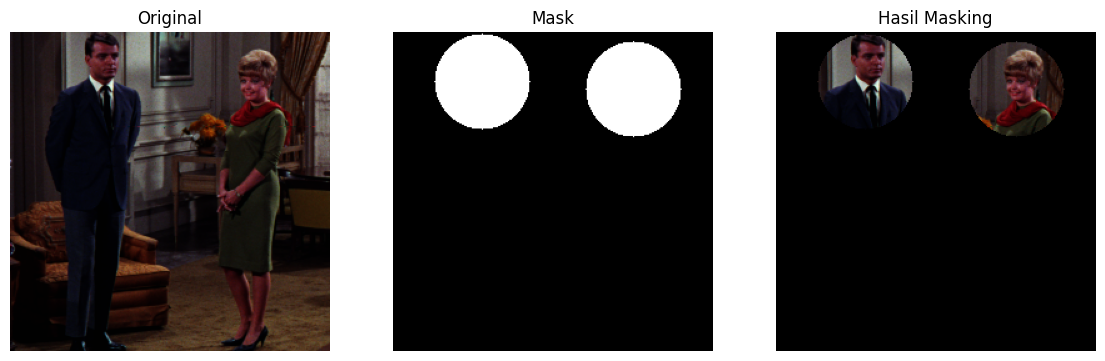

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/content/couple.tiff')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Cek ukuran gambar
h, w, _ = img.shape
print("Ukuran Gambar:", w, "x", h)

# --- Atur koordinat kepala ---
# (cx, cy, radius)
circle1 = (int(w*0.28), int(h*0.16), int(h*0.15))  # pria
circle2 = (int(w*0.75), int(h*0.18), int(h*0.15))  # wanita

# Buat mask hitam
mask = np.zeros((h, w), dtype=np.uint8)

# Gambar dua lingkaran putih
cv2.circle(mask, (circle1[0], circle1[1]), circle1[2], 255, -1)
cv2.circle(mask, (circle2[0], circle2[1]), circle2[2], 255, -1)

# Terapkan masking
masked = cv2.bitwise_and(img, img, mask=mask)

# Tampilkan hasil
plt.figure(figsize=(14,6))
plt.subplot(1,3,1), plt.imshow(img), plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2), plt.imshow(mask, cmap='gray'), plt.title("Mask")
plt.axis('off')
plt.subplot(1,3,3), plt.imshow(masked), plt.title("Hasil Masking")
plt.axis('off')
plt.show()

## Percobaan 5 — Operator

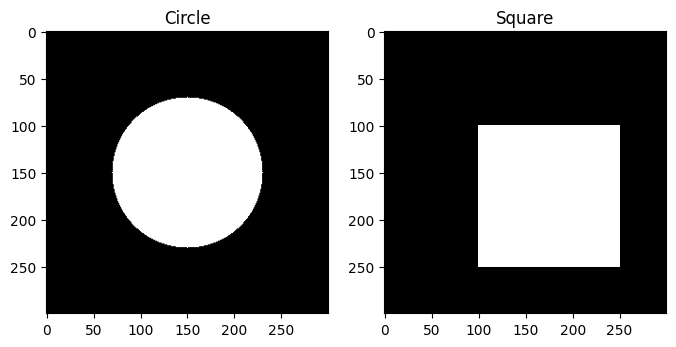

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ukuran gambar
size = 300
img1 = np.zeros((size, size), dtype=np.uint8)
img2 = np.zeros((size, size), dtype=np.uint8)

# Gambar lingkaran
cv2.circle(img1, (150,150), 80, 255, -1)

# Gambar persegi
cv2.rectangle(img2, (100,100), (250,250), 255, -1)

# Simpan gambar
cv2.imwrite('/content/circle.png', img1)
cv2.imwrite('/content/square.png', img2)

# Tampilkan
plt.figure(figsize=(8,4))
plt.subplot(1,2,1), plt.imshow(img1, cmap='gray'), plt.title("Circle")
plt.subplot(1,2,2), plt.imshow(img2, cmap='gray'), plt.title("Square")
plt.show()

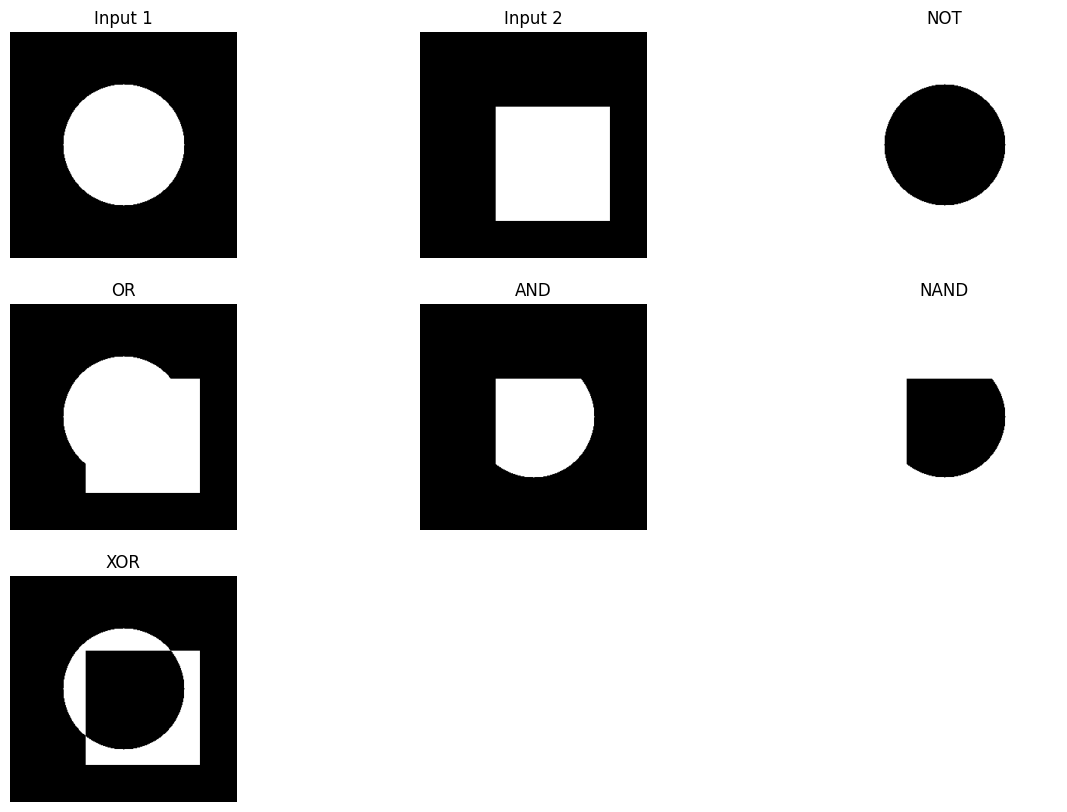

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load 2 binary images
img1 = cv2.imread('/content/circle.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/square.png', cv2.IMREAD_GRAYSCALE)

# Logic operations
not_img = cv2.bitwise_not(img1)
or_img  = cv2.bitwise_or(img1, img2)
and_img = cv2.bitwise_and(img1, img2)
nand_img = cv2.bitwise_not(and_img)
xor_img = cv2.bitwise_xor(img1, img2)

titles = ['Input 1', 'Input 2', 'NOT', 'OR', 'AND', 'NAND', 'XOR']
images = [img1, img2, not_img, or_img, and_img, nand_img, xor_img]

plt.figure(figsize=(15,10))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

Berdasarkan hasil percobaan menggunakan berbagai operator logika pada citra biner, dapat dianalisis bahwa:

1. Operator NOT (Komplemen)
Mengubah nilai piksel 0 menjadi 255 dan sebaliknya, sehingga bagian objek yang semula putih menjadi hitam, dan latar belakang yang hitam menjadi putih. Perubahan ini menunjukkan konsep kebalikan warna secara keseluruhan.

2. Operator OR (Atau)
Menghasilkan citra gabungan dari kedua gambar. Jika salah satu gambar memiliki piksel putih pada posisi tertentu, maka hasilnya tetap putih. Oleh karena itu, hasil keluaran terlihat mencakup bentuk objek dari kedua citra input.

3. Operator AND (Dan)
Hasil citra hanya menampilkan area yang sama-sama putih pada kedua gambar. Jika salah satu piksel hitam, maka piksel keluaran juga hitam. Maka, hanya bagian irisan dari kedua objek yang terlihat.

4. Operator NAND (Not And)
Merupakan komplemen dari hasil AND. Area irisan objek akan menjadi hitam dan bagian lain menjadi putih. Menghasilkan citra dengan objek terbalik dari hasil AND.

5. Operator XOR (Exclusive Or)
Hasil citra menampilkan bagian objek yang berbeda pada kedua citra input. Piksel hanya putih jika pada posisi tersebut hanya salah satu gambar yang memiliki piksel putih. Sehingga area yang sama pada kedua gambar menghilang, menyisakan hanya bentuk yang tidak overlapped.